# Otimização de Hiperparâmetros para uma rede neural tipo PINN

Este notebook tem como objetivo realizar uma breve explanação de Redes Neurais Informadas por Física (PINNs, da versão em inglês), com foco no processo de otimização dos hiperparâmetros da Rede.

**Autor**: Edélio Gabriel Magalhães de Jesus.

## Introdução

### **O que são PINNs?**

As redes neurais tradicionais ajustam seus parâmetros a partir da minimização de uma função de custo. Elas fazem isso comparando os valores previstos com os dados fornecidos. 

E se, no entanto, o número de dados fornecidos não for grande o suficiente mas, em contrapartida, sabemos como nosso problema se comporta e ainda mais, sabemos como descrevê-lo a partir de uma equação?

É aí que entram as *Physics Informed Neural Networks (PINNs)*! Elas são redes neurais que incluem na funçaõ de custo um termo referente ao comportamento físico do sistema, descrito por meio de equações diferenciais! Essa informação extra auxilia no processo de aprendizagem da rede, tornando o modelo mais robusto e fisicamente explicável.

Entre as principais aplicações, podemos citar:

- Soluções aproximadas para equações diferenciais parciais e equações diferenciais ordinárias.

- Resolver problemas inversos, como estimar parâmetros de modelos a partir de dados limitados.

## O problema: Experimento de Fenda Dupla

## Implementando a Rede Neural Informada por Física

### **Importando as bibliotecas necessárias**

In [1]:
import torch.nn as nn
import torch.optim as optim
import torch
import matplotlib.pyplot as plt

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Usando: {device}')

Usando: cuda


### **Criando a classe para a rede**

In [3]:
class PINN(nn.Module):
    def __init__(self, n_inputs, n_outputs, n_hidden, n_layers, activation):
        super().__init__()

        layers = []

        layers.append(nn.Linear(n_inputs, n_hidden))
        layers.append(activation)

        for _ in range(n_layers - 1):
            layers.append(nn.Linear(n_hidden, n_hidden))
            layers.append(activation)

        layers.append(nn.Linear(n_hidden, n_outputs))

        self.net = nn.Sequential(*layers)

    def forward(self, x, y, t):
        inputs = torch.cat([x, y, t], dim=1)
        outputs = self.net(inputs)

        u = outputs[:, 0:1]
        v = outputs[:, 1:2]

        return u, v

### **Função para o cálculo das derivadas**

In [4]:
def derivates(u, v, x, y, t):

    u_t = torch.autograd.grad(u, t, torch.ones_like(u), create_graph=True)[0]
    v_t = torch.autograd.grad(v, t, torch.ones_like(v), create_graph=True)[0]

    u_x = torch.autograd.grad(u, x, torch.ones_like(u), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, torch.ones_like(u_x), create_graph=True)[0]

    u_y = torch.autograd.grad(u, y, torch.ones_like(u), create_graph=True)[0]
    u_yy = torch.autograd.grad(u_y, y, torch.ones_like(u_y), create_graph=True)[0]

    v_x = torch.autograd.grad(v, x, torch.ones_like(v), create_graph=True)[0]
    v_xx = torch.autograd.grad(v_x, x, torch.ones_like(v_x), create_graph=True)[0]

    v_y = torch.autograd.grad(v, y, torch.ones_like(v), create_graph=True)[0]
    v_yy = torch.autograd.grad(v_y, y, torch.ones_like(v_y), create_graph=True)[0]

    lap_u = u_xx + u_yy
    lap_v = v_xx + v_yy

    return u_t, v_t, lap_u, lap_v

### **Função para o cálculo da função potencial**

In [5]:
def potencial(x, y, x_barreira, espessura, fenda1, fenda2):

    barreira = (x >= x_barreira) & (x <= x_barreira + espessura)

    mask_fendas = (((y >= fenda1[0]) & (y <= fenda1[1])) |
                   ((y >= fenda2[0]) & (y <= fenda2[1])))
    
    parede = barreira & ~(mask_fendas)

    V = 1000 * parede.float()

    return V

### **Função para o cálculo da perda da EDP**

In [6]:
def loss_pde(x, y, u, v, u_t, v_t, lap_u, lap_v, x_barreira, espessura, fenda1, fenda2, hbar=1, m=1):

    coef = hbar**2 / (2*m)
    
    V = potencial(x, y, x_barreira, espessura, fenda1, fenda2)

    residuo1 = u_t + coef * lap_v - V * v
    residuo2 = v_t - coef * lap_u + V * u

    return torch.mean(residuo1**2 + residuo2**2)

### **Função para o cálculo da perda da condição inicial**

In [7]:
def loss_ic(u_pred, v_pred, x, y, k, x0=-4.0, y0=0, sigma=0.5):
    pi = torch.tensor(torch.pi, device=x.device)

    norm = 1.0 / (2 * pi * sigma**2)
    gauss = norm * torch.exp(-((x - x0)**2 + (y - y0)**2) / (2 * sigma**2))

    u_true = gauss * torch.cos(k * x)
    v_true = gauss * torch.sin(k * x)

    return torch.mean((u_pred - u_true)**2 + (v_pred - v_true)**2)

### **Função para o cálculo da perda da condição de contorno**

In [8]:
def loss_bc(u_pred, v_pred):
    return torch.mean(u_pred**2 + v_pred**2)

### **Função para o cálculo da perda total**

In [9]:
def total_loss(model, data_pde, data_ic, data_bc, k, x_barreira, espessura, fenda1, fenda2, lambda_pde, lambda_ic, lambda_bc):

    x_pde, y_pde, t_pde = data_pde
    x_pde.requires_grad_(True)
    y_pde.requires_grad_(True)
    t_pde.requires_grad_(True)

    u_pde, v_pde = model(x_pde, y_pde, t_pde)
    u_t, v_t, lap_u, lap_v = derivates(u_pde, v_pde, x_pde, y_pde, t_pde)
    L_pde = loss_pde(x_pde, y_pde, u_pde, v_pde, u_t, v_t, lap_u, lap_v, x_barreira, espessura, fenda1, fenda2)

    x_ic, y_ic, t_ic = data_ic
    u_ic, v_ic = model(x_ic, y_ic, t_ic)
    L_ic = loss_ic(u_ic, v_ic, x_ic, y_ic, k)
    
    x_bc, y_bc, t_bc = data_bc
    u_bc, v_bc = model(x_bc, y_bc, t_bc)
    L_bc = loss_bc(u_bc, v_bc)

    return lambda_pde * L_pde + lambda_ic * L_ic + lambda_bc * L_bc

### **Funções de amostragem**

In [10]:
def sample_pde(N, focus_ratio=0.3):
    """
    N: número total de pontos PDE
    focus_ratio: fração de pontos focados nas fendas
    """
    N_focus = int(N * focus_ratio)
    N_uniform = N - N_focus

    # ── Pontos uniformes no domínio ───────────────────────────────
    x_uniform = (10 * torch.rand(N_uniform, 1) - 5).to(device)  # x ∈ [-5, 5]
    y_uniform = (2  * torch.rand(N_uniform, 1) - 1).to(device)  # y ∈ [-1, 1]
    t_uniform = (torch.rand(N_uniform, 1)).to(device)

    # ── Pontos focados nas fendas ────────────────────────────────
    # Ajuste x_barreira, fenda1 e fenda2 de acordo com sua configuração
    sigma_x = 0.01  # espalhamento em x
    sigma_y = 0.01  # espalhamento em y
    x_focus = x_barreira + sigma_x * torch.randn(N_focus, 1)
    
    # distribui metade dos pontos para cada fenda
    mask = torch.rand(N_focus) > 0.5
    y_focus = torch.zeros(N_focus, 1)
    y_focus[mask]  = fenda1 + sigma_y * torch.randn(mask.sum(), 1)
    y_focus[~mask] = fenda2 + sigma_y * torch.randn((~mask).sum(), 1)

    t_focus = torch.rand(N_focus, 1).to(device)

    # ── Combina os pontos ───────────────────────────────────────
    x = torch.cat([x_uniform, x_focus], dim=0).to(device)
    y = torch.cat([y_uniform, y_focus], dim=0).to(device)
    t = torch.cat([t_uniform, t_focus], dim=0).to(device)

    return x, y, t

def sample_ic(N):
    x = (10 * torch.rand(N, 1) - 5).to(device)  # x ∈ [-5, 5]
    y = (2  * torch.rand(N, 1) - 1).to(device)  # y ∈ [-1, 1]
    t = (torch.zeros(N, 1)).to(device)
    return x, y, t

def sample_bc(N):
    N_side = N // 4

    # Borda x = -5
    x1 = (-5 * torch.ones(N_side, 1)).to(device)
    y1 = (2  * torch.rand(N_side, 1) - 1).to(device)
    t1 = (torch.rand(N_side, 1)).to(device)

    # Borda x = 5
    x2 = (5 * torch.ones(N_side, 1)).to(device)
    y2 = (2 * torch.rand(N_side, 1) - 1).to(device)
    t2 = (torch.rand(N_side, 1)).to(device)

    # Borda y = -1
    x3 = (10 * torch.rand(N_side, 1) - 5).to(device)
    y3 = (-torch.ones(N_side, 1)).to(device)
    t3 = (torch.rand(N_side, 1)).to(device)

    # Borda y = 1
    x4 = (10 * torch.rand(N_side, 1) - 5).to(device)
    y4 = (torch.ones(N_side, 1)).to(device)
    t4 = (torch.rand(N_side, 1)).to(device)

    x = (torch.cat([x1, x2, x3, x4], dim=0)).to(device)
    y = (torch.cat([y1, y2, y3, y4], dim=0)).to(device)
    t = (torch.cat([t1, t2, t3, t4], dim=0)).to(device)

    return x, y, t

## Treinando a rede

Tendo definidas todas as funções necessárias, vamos treinar a rede com uma arquitetura simples e avaliá-la.

In [13]:
model_teste = [3, 2, 32, 3, nn.Tanh()]
model = PINN(*model_teste).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
k = 5
fenda1 = (-0.8, -0.4)
fenda2 = (0.4, 0.8)
x_barreira = 0
espessura = 0.3
N_PDE = 20000
N_IC = 500
N_BC = 500

Epoch 0 | Train: 330.954010 | Val: 158.038086
Epoch 100 | Train: 0.284469 | Val: 0.249521
Epoch 200 | Train: 0.124996 | Val: 0.110235
Epoch 300 | Train: 0.061607 | Val: 0.063514
Epoch 400 | Train: 0.049838 | Val: 0.047716
Epoch 500 | Train: 0.050365 | Val: 0.041386
Epoch 600 | Train: 0.048745 | Val: 0.033713
Epoch 700 | Train: 0.038410 | Val: 0.031477
Epoch 800 | Train: 0.028541 | Val: 0.029437
Epoch 900 | Train: 0.031265 | Val: 0.025116
Epoch 1000 | Train: 0.031745 | Val: 0.024246
Epoch 1100 | Train: 0.027256 | Val: 0.022435
Epoch 1200 | Train: 0.022907 | Val: 0.021023
Epoch 1300 | Train: 0.026799 | Val: 0.020359
Epoch 1400 | Train: 0.024513 | Val: 0.020224
Epoch 1500 | Train: 0.018221 | Val: 0.019983
Epoch 1600 | Train: 0.021402 | Val: 0.019134
Epoch 1700 | Train: 0.018973 | Val: 0.018632
Epoch 1800 | Train: 0.020285 | Val: 0.018455
Epoch 1900 | Train: 0.018029 | Val: 0.017729
Epoch 2000 | Train: 0.025206 | Val: 0.018689
Epoch 2100 | Train: 0.019740 | Val: 0.019135
Epoch 2200 | Train

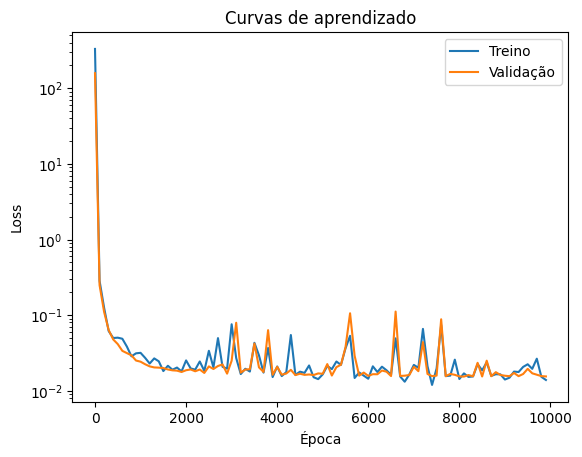

In [14]:
x_val, y_val, t_val = sample_pde(N_PDE)
x_val.requires_grad_(True)
y_val.requires_grad_(True)
t_val.requires_grad_(True)
x_ic_val, y_ic_val, t_ic_val = sample_ic(N_IC)
x_bc_val, y_bc_val, t_bc_val = sample_bc(N_BC)

train_losses = []
val_losses = []
epochs_log = []

for epoch in range(10000):
    model.train()  # garante modo treino no início de cada época
    data_pde = sample_pde(N_PDE)
    data_ic  = sample_ic(N_IC)
    data_bc  = sample_bc(N_BC)

    optimizer.zero_grad()
    loss_train = total_loss(model, data_pde, data_ic, data_bc,
                            k, x_barreira, espessura, fenda1, fenda2,
                            lambda_pde=1, lambda_ic=1, lambda_bc=1)
    loss_train.backward()
    optimizer.step()

    if epoch % 100 == 0:
        model.eval()
        with torch.enable_grad():
            loss_val = total_loss(model,
                            (x_val, y_val, t_val),
                            (x_ic_val, y_ic_val, t_ic_val),
                            (x_bc_val, y_bc_val, t_bc_val),
                            k, x_barreira, espessura, fenda1, fenda2,
                            lambda_pde=1, lambda_ic=1, lambda_bc=1)
        model.train()

        train_losses.append(loss_train.item())
        val_losses.append(loss_val.item())
        epochs_log.append(epoch)
        print(f'Epoch {epoch} | Train: {loss_train.item():.6f} | Val: {loss_val.item():.6f}')

# --- Plot ---
plt.plot(epochs_log, train_losses, label='Treino')
plt.plot(epochs_log, val_losses, label='Validação')
plt.yscale('log')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.title('Curvas de aprendizado')
plt.show()

### **Otimização com Optuna**

In [15]:
import optuna
import torch
import torch.nn as nn

def objective(trial):

    # ── Hiperparâmetros a otimizar ────────────────────────────────────────
    n_layers   = trial.suggest_int('n_layers', 2, 8)
    n_hidden   = trial.suggest_categorical('n_hidden', [64, 128, 256])
    lr         = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    lambda_pde = trial.suggest_float('lambda_pde', 0.1, 10.0)
    lambda_ic  = trial.suggest_float('lambda_ic',  0.1, 10.0)
    lambda_bc  = trial.suggest_float('lambda_bc',  0.1, 10.0)
    activation_name = trial.suggest_categorical('activation', ['Tanh', 'SiLU'])

    activation_map = {
        'Tanh': nn.Tanh(),
        'SiLU': nn.SiLU(),
    }

    activation = activation_map[activation_name]

    # ── Modelo e otimizador ───────────────────────────────────────────────
    model = PINN(3, 2, n_hidden, n_layers, activation_map[activation_name]).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # ── Dados de validação fixos ──────────────────────────────────────────
    x_val, y_val, t_val = sample_pde(N_PDE)
    x_val.requires_grad_(True)
    y_val.requires_grad_(True)
    t_val.requires_grad_(True)
    x_ic_val, y_ic_val, t_ic_val = sample_ic(N_IC)
    x_bc_val, y_bc_val, t_bc_val = sample_bc(N_BC)

    N_EPOCHS  = 3000
    LOG_EVERY = 300

    for epoch in range(N_EPOCHS):
        model.train()
        data_pde = sample_pde(N_PDE)
        data_ic  = sample_ic(N_IC)
        data_bc  = sample_bc(N_BC)

        optimizer.zero_grad()
        loss_train = total_loss(model, data_pde, data_ic, data_bc,
                                k, x_barreira, espessura, fenda1, fenda2,
                                lambda_pde, lambda_ic, lambda_bc)
        loss_train.backward()
        optimizer.step()

        if epoch % LOG_EVERY == 0 and epoch > 0:
            model.eval()
            with torch.enable_grad():
                loss_val = total_loss(model,
                                (x_val, y_val, t_val),
                                (x_ic_val, y_ic_val, t_ic_val),
                                (x_bc_val, y_bc_val, t_bc_val),
                                k, x_barreira, espessura, fenda1, fenda2,
                                lambda_pde, lambda_ic, lambda_bc)
            model.train()

            trial.report(loss_val.item(), epoch)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()

    # ── Métrica final: só a loss de validação ─────────────────────────────
    model.eval()
    with torch.enable_grad():
        loss_val_final = total_loss(model,
                            (x_val, y_val, t_val),
                            (x_ic_val, y_ic_val, t_ic_val),
                            (x_bc_val, y_bc_val, t_bc_val),
                            k, x_barreira, espessura, fenda1, fenda2,
                            lambda_pde, lambda_ic, lambda_bc)

    return loss_val_final.item()


# ── Rodando o estudo ──────────────────────────────────────────────────────────
sampler = optuna.samplers.TPESampler(seed=42)
pruner  = optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=300)

study = optuna.create_study(
    direction='minimize',
    sampler=sampler,
    pruner=pruner,
    study_name='pinn_schrodinger'
)

study.optimize(objective, n_trials=30, show_progress_bar=True)

# ── Resultados ────────────────────────────────────────────────────────────────
print("\nMelhores hiperparâmetros:")
for chave, valor in study.best_params.items():
    print(f"  {chave}: {valor}")
print(f"\nMelhor score: {study.best_value:.6f}")

[I 2026-03-25 21:36:29,035] A new study created in memory with name: pinn_schrodinger


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-03-25 21:36:59,590] Trial 0 finished with value: 0.012808739207684994 and parameters: {'n_layers': 4, 'n_hidden': 64, 'lr': 0.0002051338263087451, 'lambda_pde': 8.64373149647393, 'lambda_ic': 0.6750277604651747, 'lambda_bc': 8.675143843171858, 'activation': 'SiLU'}. Best is trial 0 with value: 0.012808739207684994.
[I 2026-03-25 21:37:48,381] Trial 1 finished with value: 0.09768654406070709 and parameters: {'n_layers': 7, 'n_hidden': 64, 'lr': 0.00023270677083837802, 'lambda_pde': 15.907869905017348, 'lambda_ic': 5.295088673159155, 'lambda_bc': 4.376255684556946, 'activation': 'SiLU'}. Best is trial 0 with value: 0.012808739207684994.
[I 2026-03-25 21:38:11,747] Trial 2 finished with value: 0.10466074198484421 and parameters: {'n_layers': 4, 'n_hidden': 256, 'lr': 0.00025081156860452336, 'lambda_pde': 26.19748748226697, 'lambda_ic': 5.96490423173422, 'lambda_bc': 0.5598590859279775, 'activation': 'Tanh'}. Best is trial 0 with value: 0.012808739207684994.
[I 2026-03-25 21:38:48,

{'n_layers': 6, 'n_hidden': 64, 'lr': 0.002205888596467701, 'lambda_pde': 6.051366634714308, 'lambda_ic': 0.11650998125786483, 'lambda_bc': 9.978491006965847, 'activation': 'SiLU'}
Epoch 0 | Train: 595.201477 | Val: 262.736023
Epoch 100 | Train: 0.005782 | Val: 0.003718
Epoch 200 | Train: 0.002213 | Val: 0.001964
Epoch 300 | Train: 0.002052 | Val: 0.001932
Epoch 400 | Train: 0.002385 | Val: 0.001920
Epoch 500 | Train: 0.002324 | Val: 0.001910
Epoch 600 | Train: 0.002031 | Val: 0.001906
Epoch 700 | Train: 0.001693 | Val: 0.001903
Epoch 800 | Train: 0.001665 | Val: 0.001902
Epoch 900 | Train: 0.002132 | Val: 0.001902
Epoch 1000 | Train: 0.001579 | Val: 0.001898
Epoch 1100 | Train: 0.002098 | Val: 0.001907
Epoch 1200 | Train: 0.002365 | Val: 0.002643
Epoch 1300 | Train: 0.003555 | Val: 0.033851
Epoch 1400 | Train: 0.005106 | Val: 0.001901
Epoch 1500 | Train: 0.001923 | Val: 0.001895
Epoch 1600 | Train: 0.001488 | Val: 0.001894
Epoch 1700 | Train: 0.001534 | Val: 0.001894
Epoch 1800 | Trai

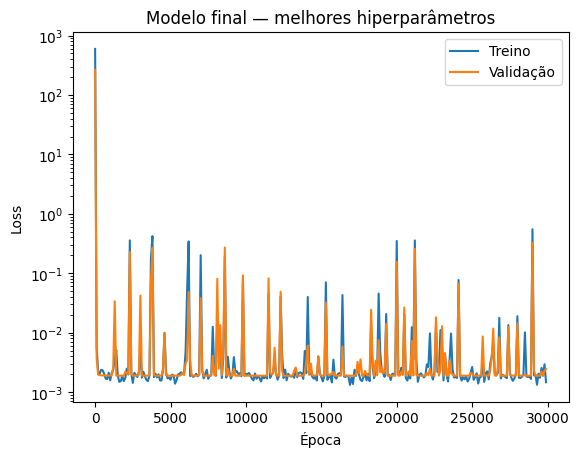

In [16]:
# ── Recupera os melhores hiperparâmetros ──────────────────────────────────────
best = study.best_params
print(best)

# ── Treina o modelo final ─────────────────────────────────────────────────────
activation_map = {
    'Tanh': nn.Tanh(),
    'SiLU': nn.SiLU(),
    'ELU':  nn.ELU()
}

model_final = PINN(3, 2, best['n_hidden'], best['n_layers'], activation_map[best['activation']]).to(device)
optimizer_final = torch.optim.Adam(model_final.parameters(), lr=best['lr'])

x_val, y_val, t_val = sample_pde(5000)
x_val.requires_grad_(True)
y_val.requires_grad_(True)
t_val.requires_grad_(True)
x_ic_val, y_ic_val, t_ic_val = sample_ic(1000)
x_bc_val, y_bc_val, t_bc_val = sample_bc(1000)

train_losses = []
val_losses   = []
epochs_log   = []

for epoch in range(30000):
    model_final.train()
    data_pde = sample_pde(5000)
    data_ic  = sample_ic(1000)
    data_bc  = sample_bc(1000)

    optimizer_final.zero_grad()
    loss_train = total_loss(model_final, data_pde, data_ic, data_bc,
                            k, x_barreira, espessura, fenda1, fenda2,
                            best['lambda_pde'], best['lambda_ic'], best['lambda_bc'])
    loss_train.backward()
    optimizer_final.step()

    if epoch % 100 == 0:
        model_final.eval()
        with torch.enable_grad():
            loss_val = total_loss(model_final,
                            (x_val, y_val, t_val),
                            (x_ic_val, y_ic_val, t_ic_val),
                            (x_bc_val, y_bc_val, t_bc_val),
                            k, x_barreira, espessura, fenda1, fenda2,
                            best['lambda_pde'], best['lambda_ic'], best['lambda_bc'])
        model_final.train()

        train_losses.append(loss_train.item())
        val_losses.append(loss_val.item())
        epochs_log.append(epoch)
        print(f'Epoch {epoch} | Train: {loss_train.item():.6f} | Val: {loss_val.item():.6f}')

# ── Plot ──────────────────────────────────────────────────────────────────────
plt.plot(epochs_log, train_losses, label='Treino')
plt.plot(epochs_log, val_losses, label='Validação')
plt.yscale('log')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.title('Modelo final — melhores hiperparâmetros')
plt.show()

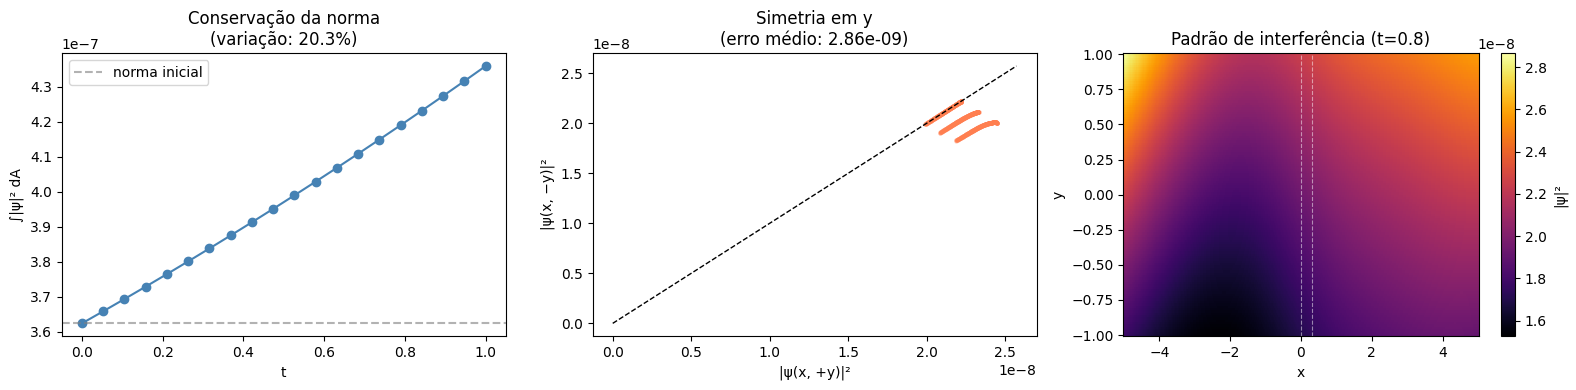

RELATÓRIO DOS TESTES
1. Norma: variação de 20.27% ao longo do tempo
   → ideal: < 5% | ATENÇÃO
2. Simetria: erro médio = 2.86e-09
   → ideal: < 1e-3  | OK
3. Interferência: verifique visualmente se há franjas após x=0.3


In [17]:
import numpy as np
import matplotlib.pyplot as plt
import torch

def teste_norma(model, N=200, T=1.0, n_tempos=10, device='cpu'):
    model.eval()
    x_lin = torch.linspace(-5, 5, N).to(device)
    y_lin = torch.linspace(-1, 1, N // 5).to(device)
    xx, yy = torch.meshgrid(x_lin, y_lin, indexing='ij')
    xx = xx.reshape(-1, 1)
    yy = yy.reshape(-1, 1)

    tempos = torch.linspace(0, T, n_tempos).to(device)
    normas = []

    dx = 10.0 / (N - 1)
    dy = 2.0  / (N // 5 - 1)
    area_celula = dx * dy

    with torch.no_grad():
        for t_val in tempos:
            tt = t_val * torch.ones_like(xx)
            u, v = model(xx, yy, tt)
            psi2 = (u**2 + v**2).cpu().numpy()
            norma = psi2.sum() * area_celula
            normas.append(norma)

    return tempos.cpu().numpy(), np.array(normas)


def teste_simetria(model, N=300, t_fixo=0.8, device='cpu'):
    model.eval()
    x_lin = torch.linspace(0.5, 5, N).to(device)
    y_lin = torch.linspace(0, 1, N // 2).to(device)

    xx, yy = torch.meshgrid(x_lin, y_lin, indexing='ij')
    xx_flat = xx.reshape(-1, 1)
    yy_flat = yy.reshape(-1, 1)
    tt      = t_fixo * torch.ones_like(xx_flat)
    yy_neg  = -yy_flat

    with torch.no_grad():
        u_pos, v_pos = model(xx_flat, yy_flat, tt)
        u_neg, v_neg = model(xx_flat, yy_neg, tt)

    psi2_pos = (u_pos**2 + v_pos**2).cpu().numpy()
    psi2_neg = (u_neg**2 + v_neg**2).cpu().numpy()
    erro_simetria = np.abs(psi2_pos - psi2_neg).mean()

    return psi2_pos, psi2_neg, erro_simetria


def teste_interferencia(model, N=300, t_fixo=0.8, device='cpu'):
    model.eval()
    x_lin = torch.linspace(-5, 5, N).to(device)
    y_lin = torch.linspace(-1, 1, N // 5 * 2).to(device)

    xx, yy = torch.meshgrid(x_lin, y_lin, indexing='ij')
    xx_flat = xx.reshape(-1, 1)
    yy_flat = yy.reshape(-1, 1)
    tt      = t_fixo * torch.ones_like(xx_flat)

    with torch.no_grad():
        u, v = model(xx_flat, yy_flat, tt)

    psi2 = (u**2 + v**2).reshape(N, -1).cpu().numpy()
    return xx.cpu().numpy(), yy.cpu().numpy(), psi2


# ── RODANDO OS TESTES E PLOTANDO ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# — Teste 1: norma —
tempos, normas = teste_norma(model_final, N=200, T=1.0, n_tempos=20, device=device)
axes[0].plot(tempos, normas, 'o-', color='steelblue')
norma_ref = normas[0]
axes[0].axhline(norma_ref, color='gray', linestyle='--', alpha=0.6, label='norma inicial')
variacao = 100 * (normas.max() - normas.min()) / norma_ref
axes[0].set_title(f'Conservação da norma\n(variação: {variacao:.1f}%)')
axes[0].set_xlabel('t')
axes[0].set_ylabel('∫|ψ|² dA')
axes[0].legend()

# — Teste 2: simetria —
psi2_pos, psi2_neg, erro = teste_simetria(model_final, N=300, t_fixo=0.8, device=device)
axes[1].scatter(psi2_pos.flatten()[::50],
                psi2_neg.flatten()[::50],
                alpha=0.3, s=5, color='coral')
lim = max(psi2_pos.max(), psi2_neg.max())
axes[1].plot([0, lim], [0, lim], 'k--', linewidth=1)
axes[1].set_title(f'Simetria em y\n(erro médio: {erro:.2e})')
axes[1].set_xlabel('|ψ(x, +y)|²')
axes[1].set_ylabel('|ψ(x, −y)|²')

# — Teste 3: interferência —
xx, yy, psi2 = teste_interferencia(model_final, N=300, t_fixo=0.8, device=device)
im = axes[2].pcolormesh(xx.T, yy.T, psi2.T, cmap='inferno', shading='auto')
axes[2].axvline(0,   color='white', linewidth=0.8, linestyle='--', alpha=0.5)
axes[2].axvline(0.3, color='white', linewidth=0.8, linestyle='--', alpha=0.5)
plt.colorbar(im, ax=axes[2], label='|ψ|²')
axes[2].set_title(f'Padrão de interferência (t=0.8)')
axes[2].set_xlabel('x')
axes[2].set_ylabel('y')

plt.tight_layout()
plt.show()

# — Relatório no terminal —
print("=" * 50)
print("RELATÓRIO DOS TESTES")
print("=" * 50)
print(f"1. Norma: variação de {variacao:.2f}% ao longo do tempo")
print(f"   → ideal: < 5% | {'OK' if variacao < 5 else 'ATENÇÃO'}")
print(f"2. Simetria: erro médio = {erro:.2e}")
print(f"   → ideal: < 1e-3  | {'OK' if erro < 1e-3 else 'ATENÇÃO'}")
print("3. Interferência: verifique visualmente se há franjas após x=0.3")
print("=" * 50)